In [1]:
import sys
sys.path.append("lightecho_modeling_oop/OOP")
import SimulateLEInfPlane
from definitions import CONFIG_PATH_UTILS, CONFIG_PATH_DUST
sys.path.append(CONFIG_PATH_UTILS)

sys.path.append(CONFIG_PATH_DUST)
import var_constants as vc
import fix_constants as fc
import dust_constants as dc
from Source import Source
import numpy as np
import yaml

import matplotlib.pyplot as plt

In [203]:
with open('/pscratch/sd/t/taceroc/LE_inj/params_le_for_4026_15_2022_y.yml', 'r') as f:
    parameters_all = yaml.safe_load(f)

parameters = parameters_all[int(0)]
print(parameters)
dt0 =  parameters['dt0'] * fc.dtoy #years
d =  parameters['d'] * fc.pctoly#parameters['d']
Flmax =  dc.Flmax #parameters['dt0']
dz0 =  parameters['dz0'] * fc.pctoly
ct = parameters['ct'] * fc.dtoy#in y
a = parameters['plane_coefficients'][0]
ay = parameters['plane_coefficients'][1]
az = parameters['plane_coefficients'][2] 
z0ly = parameters['plane_coefficients'][3] * fc.pctoly
ini_angle = parameters['angles'][0]
end_angle = parameters['angles'][1]

bool_save = False
bool_show_plots = False
wavel = parameters['wave']
source1 = Source(dt0, d, Flmax)
# for io, wavel in zip([7,5,3,1], [4.732E-01, 5.732E-01, 7.732E-01, 8.732E-01]):
# for ct in np.linspace(180, 465, 10)* fc.dtoy:
io = 7

{'Flmax': 1e+16, 'angles': [0, 360], 'ct': 640, 'd': 52000, 'dt0': 0, 'dz0': 0.06, 'plane_coefficients': [0, 0, 1, 120], 'wave': 0.567, 'loc_to_fits': '4026_15_v2/plane'}


In [230]:
initi_LE = SimulateLEInfPlane.CalculateLE(wavel, io, dz0, ct, dt0, [a, ay, az, -z0ly], [ini_angle, end_angle], source1)

True
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
/pscratch/sd/t/taceroc/LE_inj
OBS TIME 640.0


In [231]:
x_inter_values_t0, y_inter_values_t0, z_inter_values_t0, new_xs_t0, new_ys_t0, new_zs_t0, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][0],
                                                                                                                                          return_LE_plane1source1=True)


True
TIME LE elliposid in days 656.8679000000047
TIME of the SN LC respect to peak -16.867900000004738
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0


In [232]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'].min(),
                                                                                                                                          return_LE_plane1source1=True)
cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'].max(), x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

True
TIME LE elliposid in days 656.8679000000047
TIME of the SN LC respect to peak -16.867900000004738
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.463279925393064e-16
mean of rho 37.575941362184594
half_obs_thickness given by dust 0.004686218799740174
carb values
silicate values
FLUX AFTER SURFACE 4.193117401676493e-30


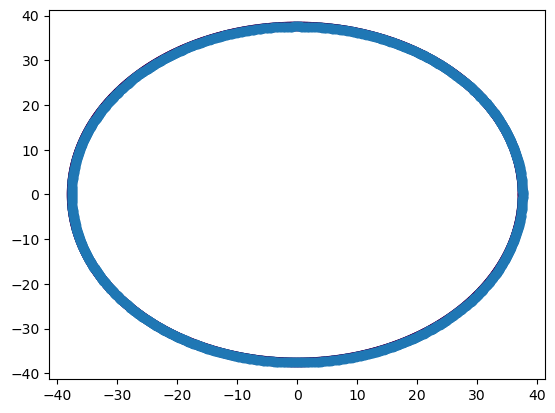

In [233]:
plt.scatter(x_inter_values_t0, y_inter_values_t0,c=np.log(surface))
plt.scatter(x_inter_values, y_inter_values)


In [234]:
from LE_img import LEImageAnalytical

In [235]:
# import astropy.cosmology.units as cu
# import astropy.units as u
# u.add_enabled_units(cu)

In [236]:
le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')
# surface_val, x_img, y_img, x_all_ly, y_all_ly, z_all_ly, z_img_ly = le_img.create_le_surface()

In [237]:
x_lim_min, x_lim_max = np.min(le_img.new_xs), np.max(le_img.new_xs)
y_lim_min, y_lim_max = np.min(le_img.new_ys), np.max(le_img.new_ys)

x_tot_arcsec = np.abs(round((x_lim_max - x_lim_min),0))
y_tot_arcsec = np.abs(round((y_lim_max - y_lim_min),0))
print("size arcsec", x_tot_arcsec, y_tot_arcsec)

x_size_img = int(x_tot_arcsec / 0.2)
y_size_img = int(y_tot_arcsec / 0.2)
print("size img pixels", x_size_img, y_size_img)
x_all, y_all = np.meshgrid(np.linspace(x_lim_min, x_lim_max, x_size_img),
    np.linspace(y_lim_min, y_lim_max, y_size_img ))


size arcsec 91.0 91.0
size img pixels 455 455


In [238]:
x_all.shape

(455, 455)

In [239]:
x_bins = np.linspace(np.nanmin(le_img.new_xs[0,0,:]), np.nanmax(le_img.new_xs[0,0,:]), x_size_img)
y_bins = np.linspace(np.nanmin(le_img.new_ys[0,0,:]), np.nanmax(le_img.new_ys[0,0,:]), y_size_img)

In [240]:
inds_x = np.digitize(le_img.new_xs[0,0,:], x_bins)
inds_y = np.digitize(le_img.new_ys[0,0,:], y_bins)
# inds_z = np.digitize(z_inter_values_t0, z_bins)

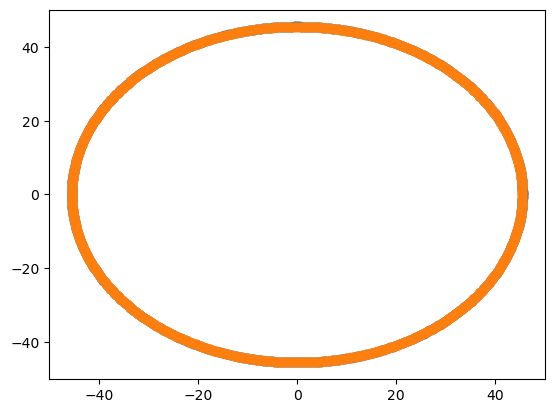

In [241]:
plt.scatter(le_img.new_xs[0,0,:],le_img.new_ys[0,0,:])
plt.scatter(le_img.new_xs[0,1,:],le_img.new_ys[0,1,:])


In [242]:
inds_x.shape

(1000,)

In [243]:
surface[0]

4.193117401676493e-30

In [244]:
matrix_surface = np.ones((x_size_img,y_size_img))*-1

In [245]:
matrix_surface.shape

(455, 455)

In [246]:
for i, (xi, yj) in enumerate(zip(inds_x, inds_y)):
    matrix_surface[xi-1, yj-1] = surface[i]
# for i, (xi, yj) in enumerate(zip(inds_x2, inds_y2)):
#     matrix_surface[xi-1, yj-1] = surface[i]
        # print(xi, yj)

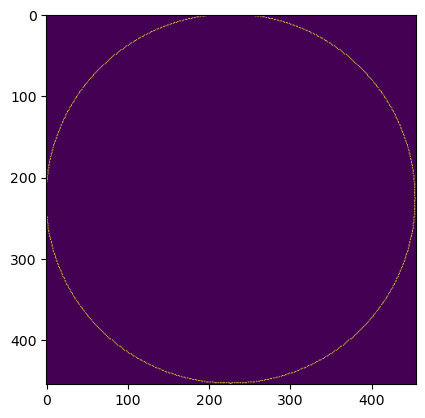

In [247]:
plt.imshow(matrix_surface)

In [248]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][-1],
                                                                                                                                          return_LE_plane1source1=True)
cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'].max(), x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')

inds_x2 = np.digitize(le_img.new_xs[0,1,:], x_bins)
inds_y2 = np.digitize(le_img.new_ys[0,1,:], y_bins)

for i, (xi, yj) in enumerate(zip(inds_x2, inds_y2)):
    matrix_surface[xi-1, yj-1] = surface[i]

True
TIME LE elliposid in days 384.6546999999991
TIME of the SN LC respect to peak 255.34530000000086
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.463279925393064e-16
mean of rho 28.740866687111744
half_obs_thickness given by dust 0.003587778106344488
carb values
silicate values
FLUX AFTER SURFACE 4.198075130120852e-30


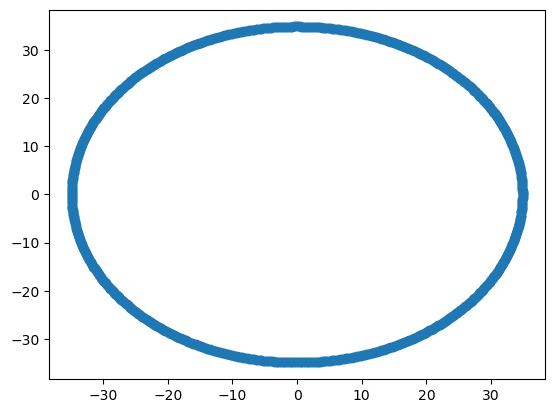

In [249]:
plt.scatter(le_img.new_xs[0,0,:], le_img.new_ys[0,0,:])

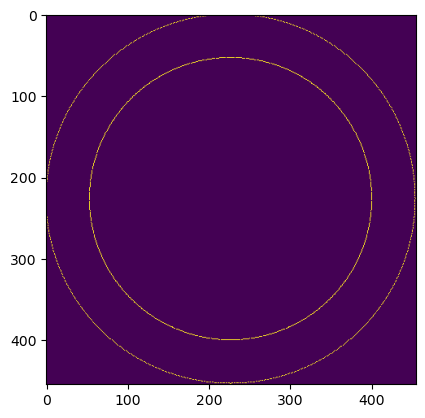

In [250]:
plt.imshow(matrix_surface)


In [253]:
x_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs, LE_plane1source1_tt = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'][::40][1],
                                                                                                                                          return_LE_plane1source1=True)
cossigma, surface = initi_LE.calculate_sb(initi_LE.lc['time'].max(), x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

le_img = LEImageAnalytical(LE_plane1source1_tt, initi_LE.plane1, surface, pixel_resolution = 0.2, cmap = 'magma_r')
surface_val, x_img, y_img, x_all_ly, y_all_ly, z_all_ly, z_img_ly = le_img.create_le_surface()

True
TIME LE elliposid in days 649.0122000000047
TIME of the SN LC respect to peak -9.012200000004668
There are (1000,) intersections points in x
There are (1000,) intersections points in y
There are (1000,) intersections points in z
Intersections
(1000,)
b 0
FLUX INTEGRAL IN TIME 7.463279925393064e-16
mean of rho 37.35006167738451
half_obs_thickness given by dust 0.004658176387406268
carb values
silicate values
FLUX AFTER SURFACE 4.193260304827101e-30
FUNC for interpolation_surface
(1000,)
size arcsec 91.0 91.0
size ly 37.35006167738451 -37.34987699318614
size img pixels 455 455
Min and Max radii of LE in arcsec
45.41343951054253 45.424769965238056
SOME VALS FOR SURFACE VAL CALCULATION
(0,)
0.0
4.1932603048271025e-30
80
no suma 0


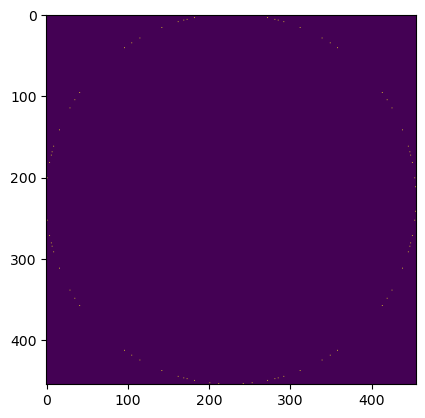

In [254]:
plt.imshow(surface_val)

In [17]:
# for idx, tt in enumerate(initi_LE.lc['time'][::40], return_LE_plane1source1=True):
#     xa_inter_values, y_inter_values, z_inter_values, new_xs, new_ys, new_zs = initi_LE.calculate_xyz_x_specific_phase_lc_time(initi_LE.lc['time'].max())
#     cossigma, surface = initi_LE.calculate_sb(tt, x_inter_values, y_inter_values, z_inter_values, LE_plane1source1_tt)

#     self.all_x_inter_values.extend(x_inter_values)
#     self.all_y_inter_values.extend(y_inter_values)
#     self.all_z_inter_values.extend(z_inter_values)
#     self.all_new_xs.extend(new_xs)
#     self.all_new_ys.extend(new_ys)
#     self.all_new_zs.extend(new_zs)
#     print("Len of z values")
#     print(len(self.all_new_zs))

#     self.all_r_le_in.extend(LE_plane1source1_tt.r_le_in)
#     self.all_r_le_out.extend(LE_plane1source1_tt.r_le_out)

#     all_surface.extend(surface)

In [15]:
inds

array([664, 664, 664, 664, 664, 664, 664, 664, 664, 664, 664, 664, 664,
       664, 664, 664, 664, 664, 664, 664, 663, 663, 663, 663, 663, 663,
       663, 663, 662, 662, 662, 662, 662, 662, 662, 661, 661, 661, 661,
       661, 660, 660, 660, 660, 660, 659, 659, 659, 659, 658, 658, 658,
       658, 657, 657, 657, 657, 656, 656, 656, 655, 655, 655, 655, 654,
       654, 654, 653, 653, 653, 652, 652, 652, 651, 651, 651, 650, 650,
       649, 649, 649, 648, 648, 647, 647, 647, 646, 646, 645, 645, 645,
       644, 644, 643, 643, 642, 642, 641, 641, 641, 640, 640, 639, 639,
       638, 638, 637, 637, 636, 636, 635, 635, 634, 634, 633, 633, 632,
       632, 631, 630, 630, 629, 629, 628, 628, 627, 627, 626, 625, 625,
       624, 624, 623, 622, 622, 621, 621, 620, 619, 619, 618, 618, 617,
       616, 616, 615, 614, 614, 613, 613, 612, 611, 611, 610, 609, 609,
       608, 607, 607, 606, 605, 605, 604, 603, 603, 602, 601, 600, 600,
       599, 598, 598, 597, 596, 596, 595, 594, 593, 593, 592, 59

In [15]:
def grid(x_inter_values, y_inter_values, z_inter_values):
        
    x_all, y_all, z_all = np.meshgrid(x_inter_values, y_inter_values, z_inter_values, indexing='ij')
    
    assert np.all(x_all[:,0,0] == x_inter_values)
    assert np.all(y_all[0,:,0] == y_inter_values)
    assert np.all(z_all[0,0,:] == z_inter_values)
    
    return x_all, y_all, z_all

x_inter_values = np.linspace(3,10,100)
y_inter_values = np.linspace(-1,2,150)
z_inter_values = np.linspace(5,6,200)
x_inter_values_g, y_inter_values_g, z_inter_values_g = grid(x_inter_values, y_inter_values, z_inter_values)

In [17]:
inds = np.digitize(x_inter_values, x_bins)

In [18]:
inds

array([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100])

In [19]:
inds_n = np.digitize(np.linspace(2,8,100), x_bins)

In [20]:
inds_n

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        1,  2,  3,  4,  4,  5,  6,  7,  8,  9, 10, 10, 11, 12, 13, 14, 15,
       16, 16, 17, 18, 19, 20, 21, 22, 22, 23, 24, 25, 26, 27, 28, 28, 29,
       30, 31, 32, 33, 34, 34, 35, 36, 37, 38, 39, 40, 40, 41, 42, 43, 44,
       45, 46, 46, 47, 48, 49, 50, 51, 52, 52, 53, 54, 55, 56, 57, 58, 58,
       59, 60, 61, 62, 63, 64, 64, 65, 66, 67, 68, 69, 70, 70, 71])

In [ ]:

SimulateLEInfPlane.plane(wavel,io, dz0, ct, dt0, [a, ay, az, -z0ly], [ini_angle, end_angle], source1, save=False, show_plots=False)